In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [13]:
df=pd.read_csv('bitcoin.csv')

In [14]:
df.head()

,Date,Open,High,Low,Close,Vol.
0,2013-01-01,13.5,13.6,13.2,13.3,28.41K
1,2013-01-02,13.3,13.4,13.2,13.3,17.97K
2,2013-01-03,13.3,13.5,13.3,13.4,18.03K
3,2013-01-04,13.4,13.5,13.3,13.5,29.64K
4,2013-01-05,13.5,13.6,13.3,13.4,21.33K


In [15]:
df.describe()

,Open,High,Low,Close
count,3793.000000,3793.000000,3793.000000,3793.000000
mean,11233.252307,11529.297996,10904.581545,11240.315766
std,15421.568722,15827.119004,14960.319732,15422.533996
min,13.300000,13.400000,13.200000,13.300000
25%,450.300000,459.600000,441.900000,451.400000
50%,5208.300000,5322.900000,5033.700000,5209.100000
75%,14976.200000,15648.300000,13902.300000,15043.000000
max,67528.700000,68990.600000,66334.900000,67527.900000


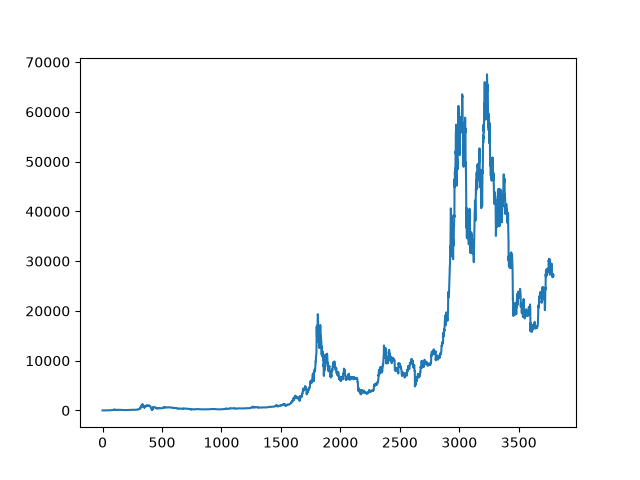

In [16]:
plt.close()
plt.Figure(figsize=(10,5))
plt.plot(df['Close'])
plt.show()

In [17]:
df.isnull().sum()
#میگه که کدوم ستون های ما خالی اند که اگه خالی بودن دیتا را تمیز کنیم

Date     0
Open     0
High     0
Low      0
Close    0
Vol.     0
dtype: int64

TypeError: subplot() takes 1 or 3 positional arguments but 2 were given

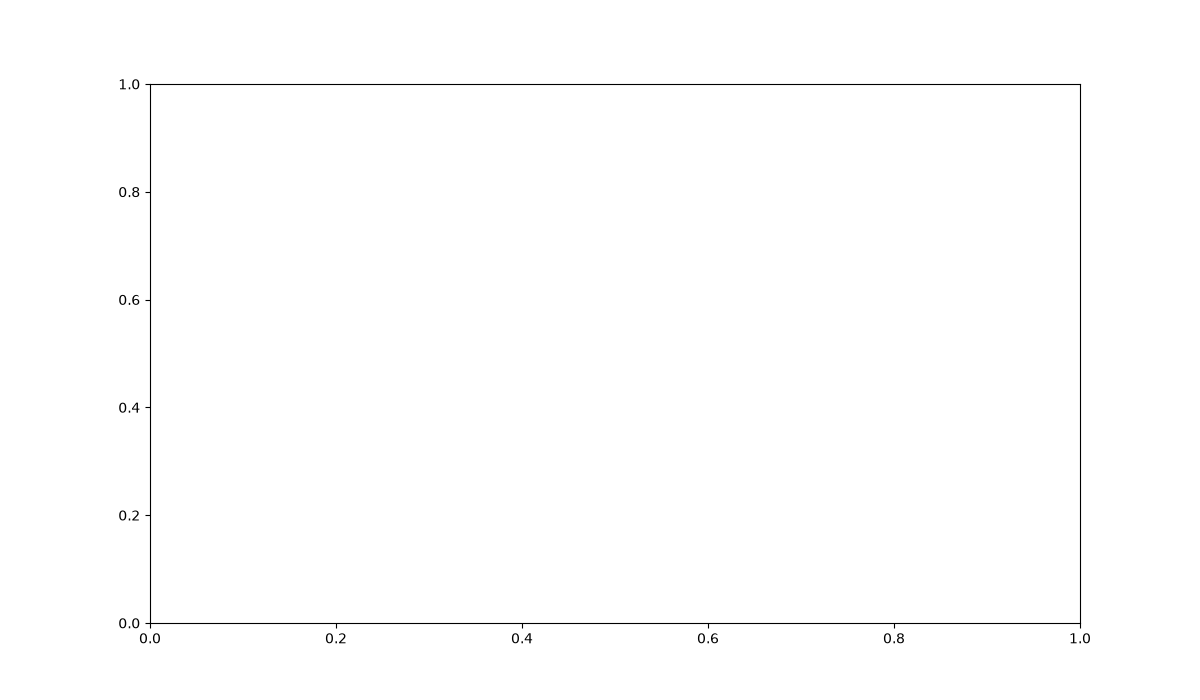

In [18]:
#نشون دادن چگال قیمتی
plt.close()
plt.subplots(figsize=(12,7))

plt.Subplot(2,2,1)
sb.plot(df['Close'])
plt.show()

C:\Users\hi\AppData\Local\Temp\ipykernel_6092\2816272304.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[col])
C:\Users\hi\AppData\Local\Temp\ipykernel_6092\2816272304.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(df[col])
C:\Users\hi\AppData\Local\Temp\ipykernel_6092\2816272304.py:6:

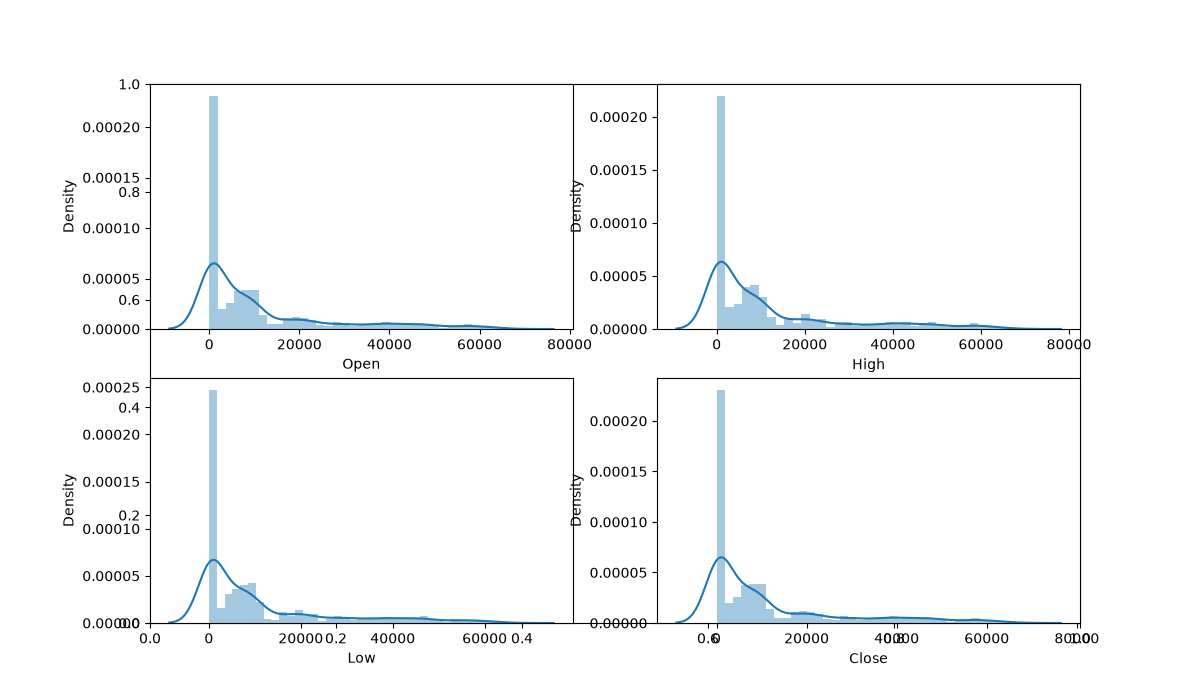

In [19]:
features = ['Open', 'High', 'Low', 'Close']
plt.close()
plt.subplots(figsize=(12,7))
for i, col in enumerate(features):
  plt.subplot(2,2,i+1)
  sb.distplot(df[col])
plt.show()

#دیتا را ویژولایز میکند و به ما نشون میده  

In [20]:
df['Date'][0]

'2013-01-01'

In [49]:
splitted = df['Date'].str.split('-', expand=True)
#اکسپند شده یعنی جدا شده

In [50]:
splitted[0]

0       2013
1       2013
2       2013
3       2013
4       2013
        ... 
3788    2023
3789    2023
3790    2023
3791    2023
3792    2023
Name: 0, Length: 3793, dtype: str

In [51]:
#مثال
a='fateme-shokri'
b=a.split('-')
print(b[1])

shokri


In [68]:
df.head()

,Date,Open,High,Low,Close,Vol.,year,month,day,is_quarter_end,open-close,low-high,target
0,2013-01-01,13.5,13.6,13.2,13.3,28.41K,2013,1,1,0,0.2,-0.4,0
1,2013-01-02,13.3,13.4,13.2,13.3,17.97K,2013,1,2,0,0.0,-0.2,1
2,2013-01-03,13.3,13.5,13.3,13.4,18.03K,2013,1,3,0,-0.1,-0.2,1
3,2013-01-04,13.4,13.5,13.3,13.5,29.64K,2013,1,4,0,-0.1,-0.2,0
4,2013-01-05,13.5,13.6,13.3,13.4,21.33K,2013,1,5,0,0.1,-0.3,0


In [ ]:
#میخواییم ستون جدیدی را اضافه کنیم

df['year'] = splitted[0].astype('int')
df['month'] = splitted[1].astype('int')
df['day'] = splitted[2].astype('int')

In [54]:
#groupby
#گروه شده
#مثلا همه سال ها را داخل یک گروه قرار میده 
#میاد از سال 2013 تا 2023 داده های هر سال را داخل یک گروه جدا قرار میده

plt.close()
data_grouped = df.groupby('year').mean()
plt.Subplot(figsize=(5,5))
plt.Subplot(1,1,1)
data_grouped['Close'].plot.bar()
plt.show()

TypeError: dtype 'str' does not support operation 'mean'

In [57]:
#where

df['is_quarter_end'] = np.where(df['month'] % 3 ==0,1,0)

#میگه اگه این شرط برقرار شد اولی را بذار اگه برقرار نشد دومی را بذار
#شرطمون (df['month'] % 3 ==0)این هست و اگر بر قرار شد 1 میذاره و اگر نه 0 میذاره

In [63]:
df['open-close'] = df['Open'] - df['Close']
df['low-high'] = df['Low'] - df['High']

In [ ]:
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
# اگه افزایش پیدا کرد 1  و در غیر این صورت 0 را پیرینت کند

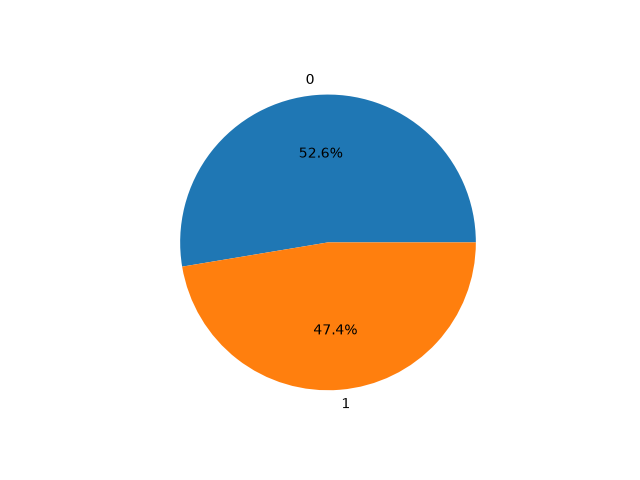

In [66]:
plt.close()
plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

In [72]:
X = df[['open-close', 'low-high', 'is_quarter_end']]
y = df['target']

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, y, test_size=0.15, random_state=2022)

print(X_train.shape, X_valid.shape)

(3224, 3) (569, 3)


In [88]:
model = DecisionTreeClassifier()
model.max_iter=1000
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [89]:
out= model.predict(X_valid)

In [90]:
out

array([0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,

In [91]:
Y_valid

2022    1
452     0
1023    1
73      0
2809    1
       ..
2293    1
804     0
1272    1
3671    1
2364    1
Name: target, Length: 569, dtype: int32

In [92]:
metrics.roc_auc_score(Y_train, model.predict_proba(X_train)[:,1])

0.9999905428153768